# Sales Performance — Exploratory Data Analysis

**Author:** Roger Amorín Suñé  
**Stack:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Dataset:** Synthetic retail sales — 1,000 transactions (2022–2023)

---

## Goal

Walk through how a junior analyst would explore a retail sales dataset:
monthly trend, category contribution, seasonality, channel mix, regional split, and per-transaction distribution.

## Note on the data

The dataset is synthetic, with **documented** effects (Q4 +20 % lift, Online ≈ 65 %, Electronics-skewed mix). The point is to show *how* to quantify and communicate them — not to discover them. The same code would work on real retail data.


## 1. Setup and dataset

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

OUT = Path("outputs"); OUT.mkdir(exist_ok=True)
print("Libraries loaded ✔")

Libraries loaded ✔


### Build the dataset

Four categories, five regions, two channels, with documented effects: +20 % Q4 lift, ~65 % Online weight, Electronics-skewed mix.

In [2]:
rng = np.random.default_rng(42)
N = 1_000

categories = ["Electronics", "Furniture", "Books", "Stationery"]
cat_weights = [0.40, 0.25, 0.20, 0.15]
regions = ["Barcelona", "Madrid", "Valencia", "Sevilla", "Bilbao"]

dates    = pd.date_range("2022-01-01", "2023-12-31", periods=N)
category = rng.choice(categories, N, p=cat_weights)
region   = rng.choice(regions, N)
channel  = rng.choice(["Online", "In-store"], N, p=[0.65, 0.35])

price_map = {"Electronics": (50, 1200), "Furniture": (80, 700),
             "Books": (10, 35),         "Stationery": (3, 25)}
unit_price = np.array([rng.uniform(*price_map[c]) for c in category])
quantity   = rng.choice([1, 2, 3], N, p=[0.70, 0.20, 0.10])
revenue    = unit_price * quantity
month      = pd.DatetimeIndex(dates).month
revenue    = revenue * np.where(month.isin([10, 11, 12]), 1.20, 1.0)

df = pd.DataFrame({
    "date": dates, "category": category, "region": region,
    "channel": channel, "unit_price": unit_price.round(2),
    "quantity": quantity, "revenue": revenue.round(2),
})
df["year"]        = df["date"].dt.year
df["month"]       = df["date"].dt.month
df["quarter"]     = df["date"].dt.quarter
df["month_label"] = df["date"].dt.to_period("M").astype(str)
df.head()

,date,category,region,channel,unit_price,quantity,revenue,year,month,quarter,month_label
0,2022-01-01 00:00:00.000000000,Books,Bilbao,In-store,10.85,1,10.85,2022,1,1,2022-01
1,2022-01-01 17:30:48.648648648,Furniture,Barcelona,In-store,503.47,1,503.47,2022,1,1,2022-01
2,2022-01-02 11:01:37.297297297,Stationery,Madrid,Online,23.91,1,23.91,2022,1,1,2022-01
3,2022-01-03 04:32:25.945945945,Books,Valencia,Online,30.73,1,30.73,2022,1,1,2022-01
4,2022-01-03 22:03:14.594594594,Electronics,Sevilla,In-store,368.78,2,737.56,2022,1,1,2022-01


## 2. Data quality and summary

In [3]:
print("Types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df[["unit_price", "quantity", "revenue"]].describe().round(2)

Types:
date           datetime64[ns]
category               object
region                 object
channel                object
unit_price            float64
quantity                int64
revenue               float64
year                    int32
month                   int32
quarter                 int32
month_label            object
dtype: object

Missing values: 0
Date range: 2022-01-01 → 2023-12-31


,unit_price,quantity,revenue
count,1000.00,1000.00,1000.00
mean,346.60,1.39,513.24
std,343.42,0.66,621.58
min,3.16,1.00,3.71
25%,23.92,1.00,31.42
50%,246.64,1.00,312.06
75%,598.49,2.00,760.69
max,1196.63,3.00,4264.93


### KPI cards

In [4]:
total = df['revenue'].sum()
q4    = df.loc[df['month'].isin([10, 11, 12]), 'revenue'].sum()
online = df.loc[df['channel'] == 'Online', 'revenue'].sum()
elec  = df.loc[df['category'] == 'Electronics', 'revenue'].sum()

print(f"Total revenue      : €{total:>10,.0f}")
print(f"Transactions       :  {len(df):>10,}")
print(f"Avg ticket         : €{df['revenue'].mean():>10,.2f}")
print(f"Q4 share           : {100*q4/total:>10.1f} %")
print(f"Online share       : {100*online/total:>10.1f} %")
print(f"Electronics share  : {100*elec/total:>10.1f} %")

Total revenue      : €   513,239
Transactions       :       1,000
Avg ticket         : €    513.24
Q4 share           :       28.2 %
Online share       :       64.1 %
Electronics share  :       70.8 %


### Category summary table

In [5]:
summary = pd.DataFrame({
    'Revenue (€)':    df.groupby('category')['revenue'].sum().round(0),
    'Transactions':   df.groupby('category')['revenue'].count(),
    'Avg Ticket (€)': df.groupby('category')['revenue'].mean().round(2),
    'Share (%)':      (df.groupby('category')['revenue'].sum()
                       / df['revenue'].sum() * 100).round(1),
}).sort_values('Revenue (€)', ascending=False)
summary

,Revenue (€),Transactions,Avg Ticket (€),Share (%)
category,,,,
Electronics,363163.0,402,903.39,70.8
Furniture,140728.0,247,569.75,27.4
Books,6338.0,200,31.69,1.2
Stationery,3010.0,151,19.93,0.6


## 3. Monthly revenue trend

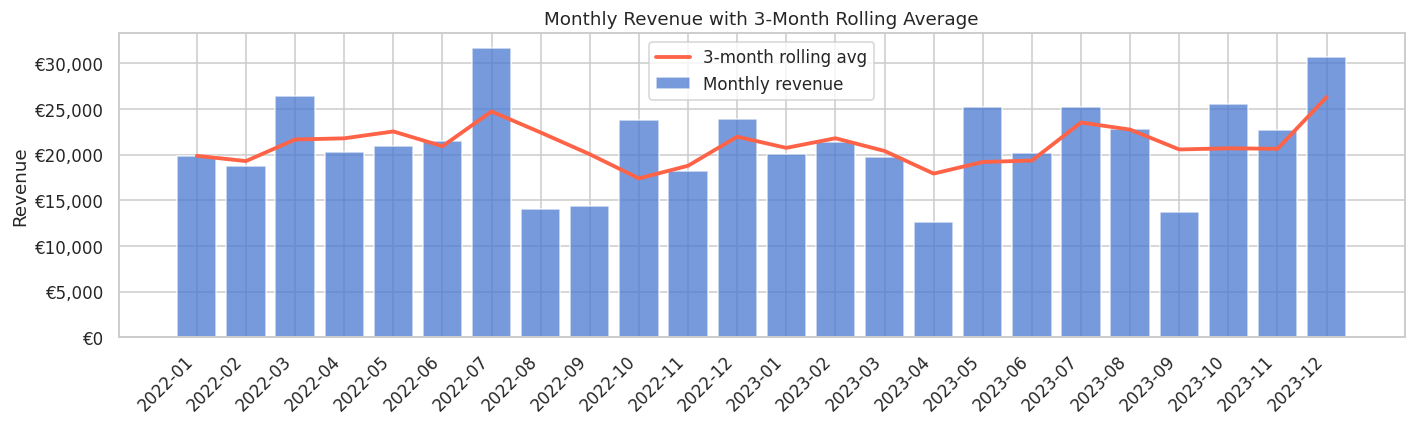

In [6]:
monthly = df.groupby('month_label')['revenue'].sum().reset_index()
monthly['rolling_avg'] = monthly['revenue'].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(monthly['month_label'], monthly['revenue'],
       color=sns.color_palette('muted')[0], alpha=0.75, label='Monthly revenue')
ax.plot(monthly['month_label'], monthly['rolling_avg'],
        color='tomato', linewidth=2.5, label='3-month rolling avg')
ax.set_title('Monthly Revenue with 3-Month Rolling Average')
ax.set_ylabel('Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig(OUT / '01_monthly_revenue.png')
plt.show()

## 4. Revenue by category

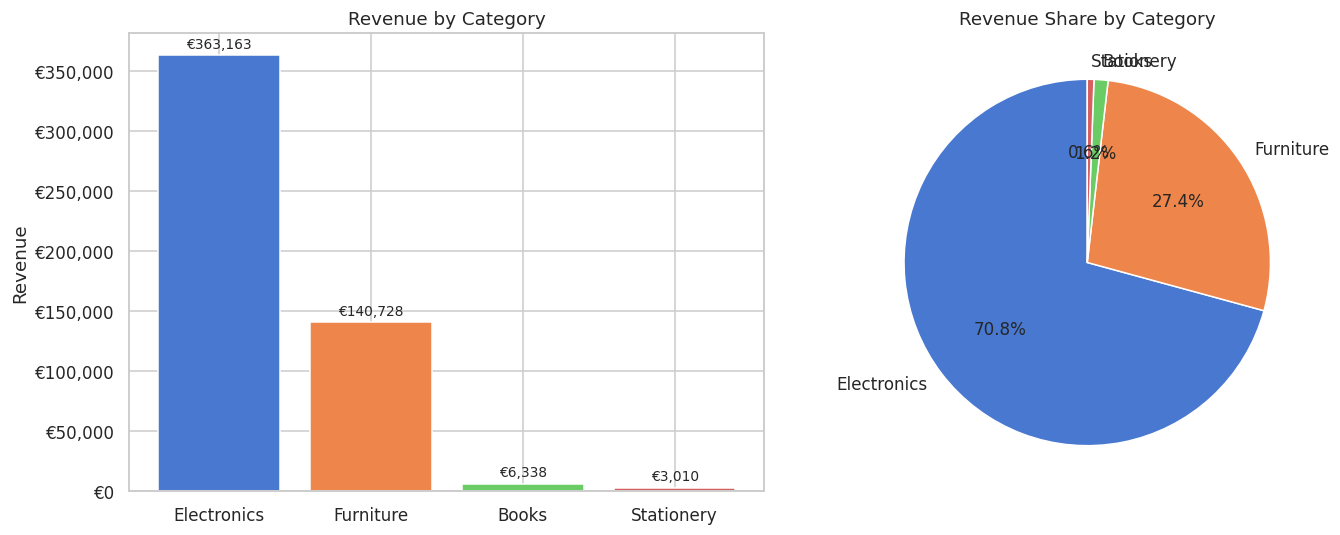

In [7]:
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = sns.color_palette('muted', len(cat_rev))

bars = axes[0].bar(cat_rev.index, cat_rev.values, color=palette)
axes[0].set_title('Revenue by Category')
axes[0].set_ylabel('Revenue')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
for bar, val in zip(bars, cat_rev.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + cat_rev.max()*0.01,
                 f'€{val:,.0f}', ha='center', va='bottom', fontsize=9)
axes[1].pie(cat_rev.values, labels=cat_rev.index,
            autopct='%1.1f%%', startangle=90, colors=palette)
axes[1].set_title('Revenue Share by Category')
plt.tight_layout()
plt.savefig(OUT / '02_revenue_by_category.png')
plt.show()

## 5. Seasonality heatmap

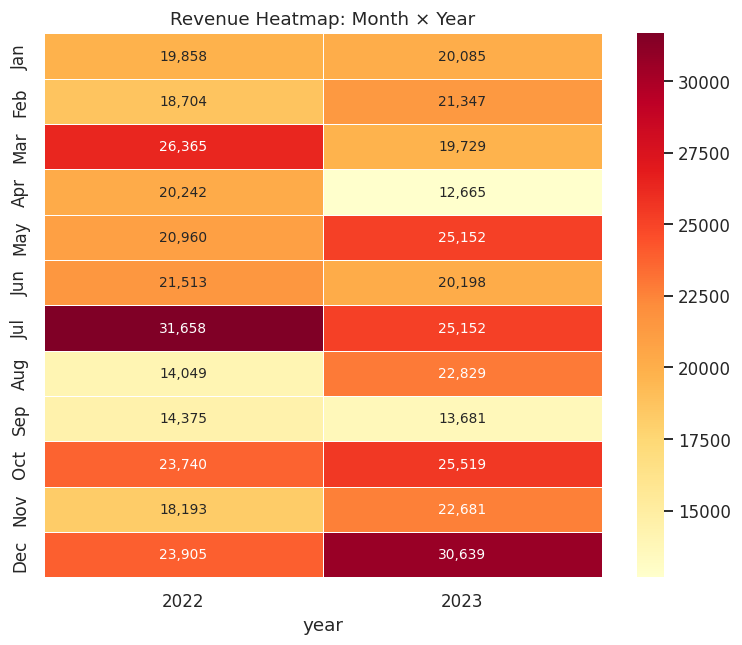

In [8]:
pivot = df.pivot_table(values='revenue', index='month', columns='year', aggfunc='sum')
pivot.index = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Revenue Heatmap: Month × Year')
plt.tight_layout()
plt.savefig(OUT / '03_seasonality_heatmap.png')
plt.show()

## 6. Channel comparison: Online vs In-store

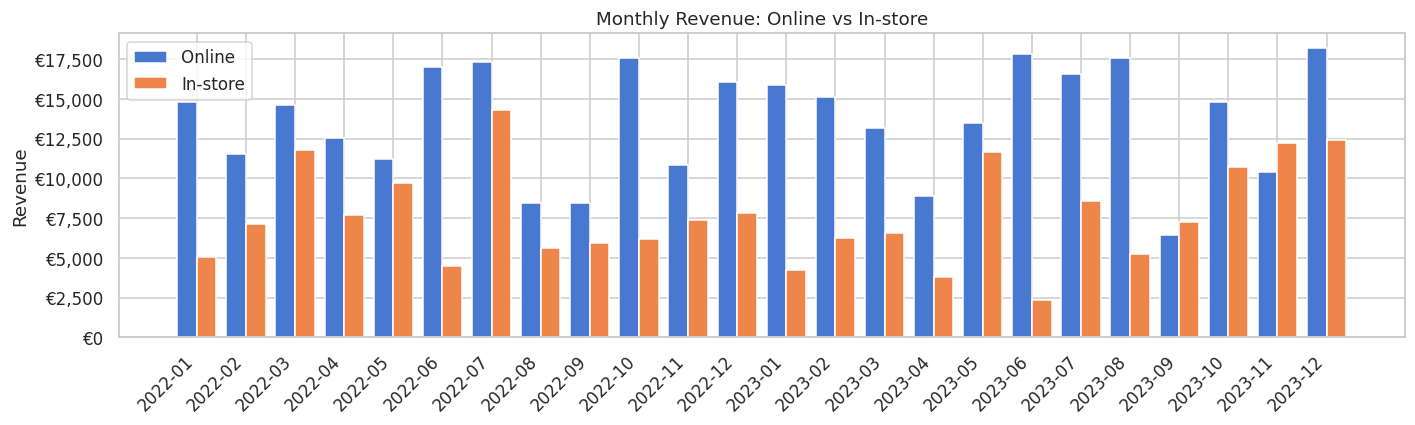

In [9]:
mc = df.groupby(['month_label', 'channel'])['revenue'].sum().unstack().reset_index()
fig, ax = plt.subplots(figsize=(13, 4))
x, w = range(len(mc)), 0.4
palette = sns.color_palette('muted')
ax.bar([i - w/2 for i in x], mc['Online'],   width=w, label='Online',   color=palette[0])
ax.bar([i + w/2 for i in x], mc['In-store'], width=w, label='In-store', color=palette[1])
ax.set_xticks(list(x))
ax.set_xticklabels(mc['month_label'], rotation=45, ha='right')
ax.set_title('Monthly Revenue: Online vs In-store')
ax.set_ylabel('Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(OUT / '04_channel_comparison.png')
plt.show()

## 7. Per-transaction distribution by category

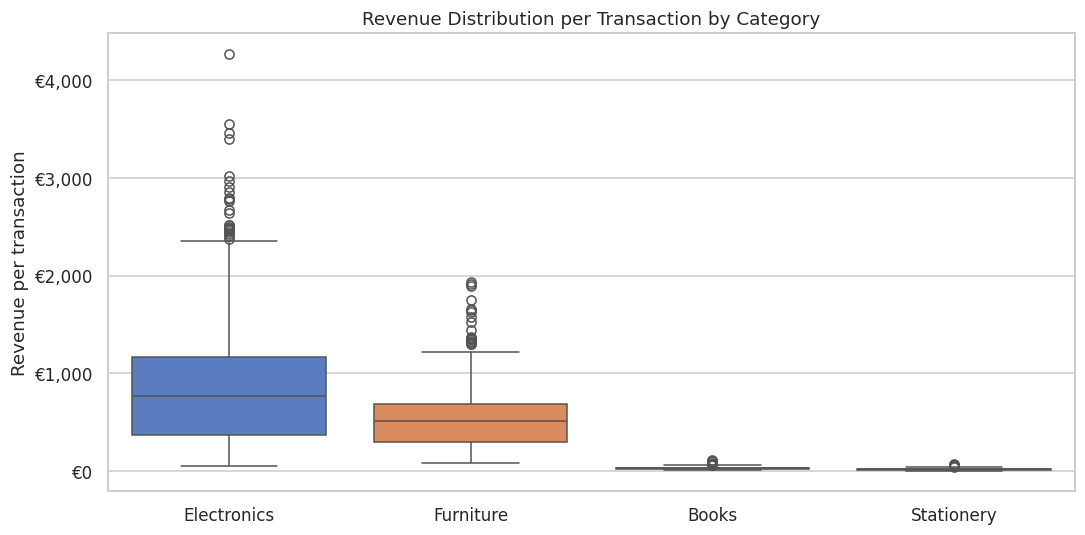

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby('category')['revenue'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='category', y='revenue', order=order, palette='muted', ax=ax)
ax.set_title('Revenue Distribution per Transaction by Category')
ax.set_xlabel('')
ax.set_ylabel('Revenue per transaction')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
plt.tight_layout()
plt.savefig(OUT / '05_revenue_distribution.png')
plt.show()

## 8. Revenue by region and category

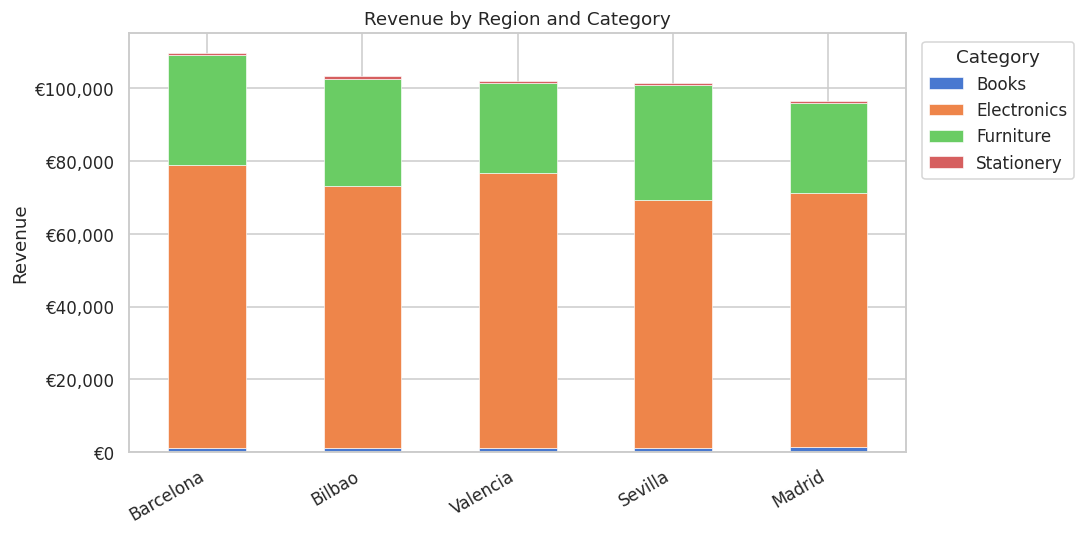

In [11]:
pr = df.groupby(['region', 'category'])['revenue'].sum().unstack().fillna(0)
pr = pr.loc[pr.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(10, 5))
pr.plot(kind='bar', stacked=True, ax=ax,
        color=sns.color_palette('muted', pr.shape[1]),
        edgecolor='white', linewidth=0.4)
ax.set_title('Revenue by Region and Category')
ax.set_xlabel('')
ax.set_ylabel('Revenue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax.legend(title='Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUT / '06_revenue_by_region.png')
plt.show()

## 9. Insight → Recommendation

| # | Insight | Recommended action |
|---|---|---|
| 1 | Electronics drive most of revenue with the highest avg ticket | Prioritise stock and promotions; protect margin during sales |
| 2 | Q4 concentrates ~28 % of annual revenue | Plan inventory and acquisition spend before October |
| 3 | Online channel is ~64 % of revenue | Continue weighting digital acquisition; track channel CAC separately |
| 4 | Electronics and Furniture have wide per-transaction spread | Test bundling and upsells; A/B placements |
| 5 | Barcelona and Madrid lead by region | Ringfence growth experiments to these markets first |

*Dataset synthetically generated with documented effects. The methodology applies unchanged to a real retail dataset.*